#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.

### You would need to submit your GitHub repository link. Refer to the PDF document for the instructions and details.





In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import distance
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [2]:
## Reading the image plaksha_Faculty.jpg
img = cv2.imread('Plaksha_Faculty.jpg')
  
## Convert the image to grayscale
imgGray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  
# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
  
# Applying the face detection method on the grayscale image. 
## Change the parameters for better detection of faces in your case.
faces_rect = face_cascade.detectMultiScale(imgGray, 1.05, 4, minSize=(25,25), maxSize=(50,50))
 
# Define the text and font parameters
text = f"Faces detected = {len(faces_rect)}" ## The text you want to write
font = cv2.FONT_HERSHEY_PLAIN  ## Font type
font_scale = 1.5  ## Font scale factor
font_color = (0,0,0)  ## Text color in BGR format (here, it's red)
font_thickness = 2  ## Thickness of the text

  
# Iterating through rectangles of detected faces
for (x, y, w, h) in faces_rect:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
    # Use cv2.putText to add the text to the image, Use text, font, font_scale, font_color, font_thickness here
    cv2.putText(img, text, (500,100), font, font_scale, font_color, font_thickness)
    
## Display the image and window title should be "Total number of face detected are #"  
cv2.imshow(f"Total no. of faces detected are {len(faces_rect)}",img)
cv2.waitKey(0)
cv2.destroyAllWindows()

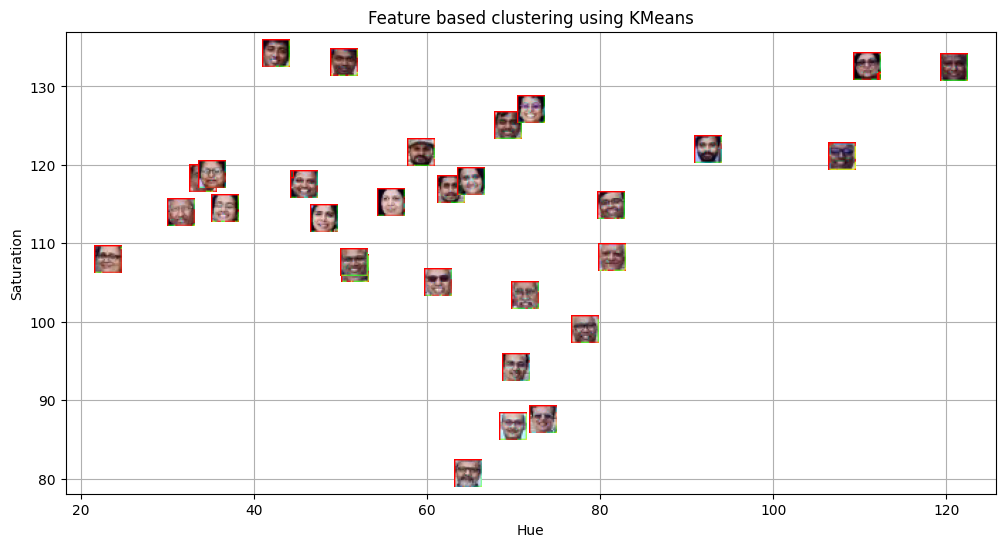

In [3]:

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV) ## call the img and convert it from BGR to HSV and store in img_hsv
hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

## Perform k-Means clustering on hue_saturation and store in kmeans
kmeans = KMeans(n_clusters=2).fit(hue_saturation)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x,y,w,h ) in enumerate(faces_rect):
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])
    

plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("Feature based clustering using KMeans")
plt.grid(True)
plt.show()

[107.98852041 121.10586735]
(np.float64(90.47899483587145), np.float64(120.28833409608372))


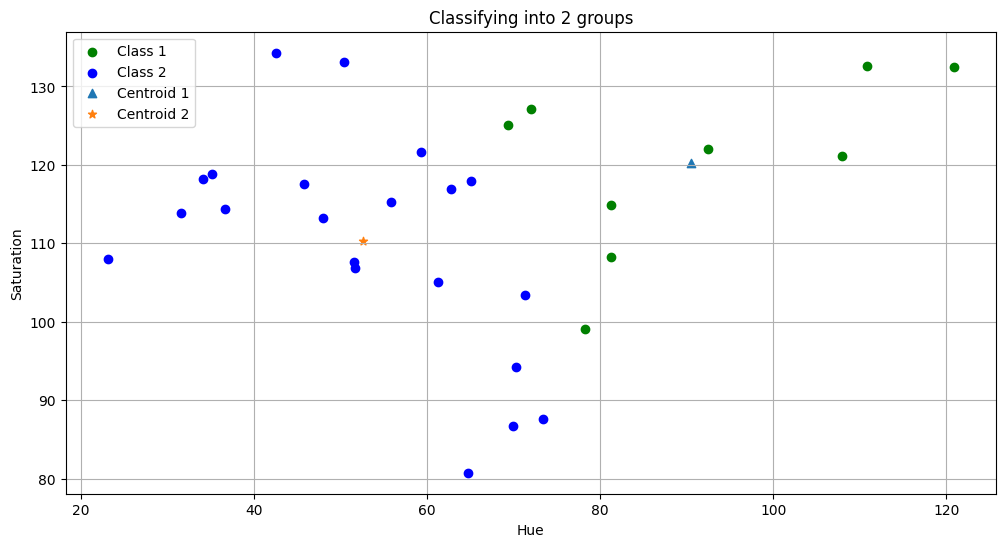

In [4]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))


cluster_0_points = np.array(cluster_0_points)
# Plot points for cluster 0 in green
print(cluster_0_points[0])
plt.scatter(cluster_0_points[:,0],cluster_0_points[:,1] ,c = "g")


cluster_1_points = np.array(cluster_1_points)
# Plot points for cluster 1 in blue
plt.scatter(cluster_1_points[:,0],cluster_1_points[:,1] ,c = "blue")



# Calculate and plot centroids
centroid_0 = np.mean(cluster_0_points[:,0]) , np.mean(cluster_0_points[:,1])
centroid_1 = np.mean(cluster_1_points[:,0]) , np.mean(cluster_1_points[:,1])
print(centroid_0)

# Plot both the centroid for cluster 0 and cluster 1 
plt.scatter(centroid_0[0],centroid_0[1] , marker = "^")
plt.scatter(centroid_1[0],centroid_1[1] , marker = "*")

plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("Classifying into 2 groups")
plt.legend(["Class 1", "Class 2" , "Centroid 1" , "Centroid 2"])
plt.grid(True)
plt.show()


In [5]:
## Read the class of the template image 'Dr_Shashi_Tharoor.jpg' using cv2 and store it in template_img
template_img = cv2.imread("Dr_Shashi_Tharoor.jpg")
# Detect face  in the template image after converting it to gray and store it in template_faces
template__img_gray = cv2.cvtColor(template_img,cv2.COLOR_BGR2GRAY)
faces_rect_ST = face_cascade.detectMultiScale(template__img_gray, 1.05, 4, minSize=(25,25), maxSize=(300,300))

template_faces = []


# Draw rectangles around the detected faces
for (x, y, w, h) in faces_rect_ST:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
cv2.imshow("Face Detection for Dr. Shahi Tharoor",template_img)
cv2.waitKey(0)
cv2.destroyAllWindows()      

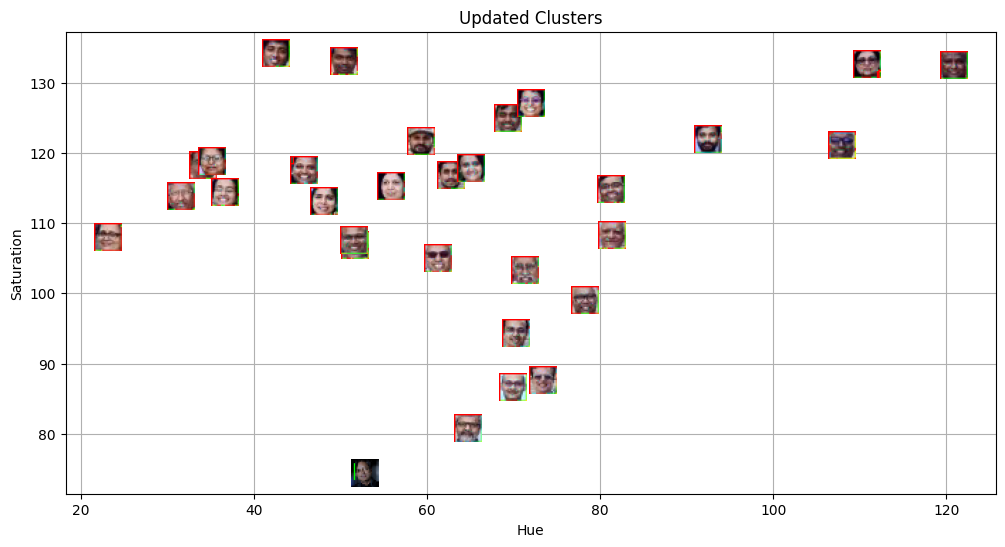

In [6]:
# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(template_img,cv2.COLOR_BGR2HSV)

face = template_hsv[y:y + h, x:x + w]
# Extract hue and saturation features from the template image as we did it for detected faces.
template_hue = np.mean(face[:,:,0])
template_saturation = np.mean(face[:,:,1])
 
# Predict the cluster label for the template image and store it in template_label

template_label = kmeans.predict(np.array([[template_hue, template_saturation]]))

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers (similar to previous code)
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1], 'o', markersize=5, color=color)

# Plot the template image in the respective cluster
if template_label == 0:
    color = 'red'
else:
    color = 'blue'

plt.scatter(template_hue, template_saturation, 
            color='pink', marker='x', s=200, label='Template Face')
im = OffsetImage(cv2.cvtColor(cv2.resize(template_img, (20, 20)), cv2.COLOR_BGR2RGB))
ab = AnnotationBbox(im, (template_hue, template_saturation), frameon=False, pad=0)
ax.add_artist(ab)

plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.grid(True)
plt.title("Updated Clusters")
plt.show()

(np.float64(90.47899483587145), np.float64(120.28833409608372))


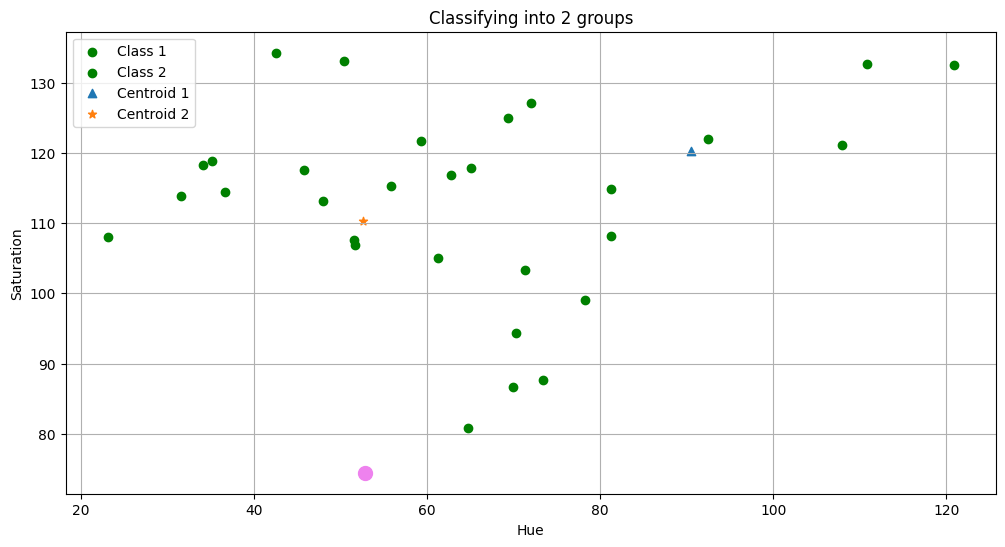

In [7]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
plt.scatter(cluster_0_points[:,0],cluster_0_points[:,1] ,c = "g")

# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
plt.scatter(cluster_1_points[:,0],cluster_1_points[:,1] ,c = "g")

# Calculate and plot centroids for both the clusters
centroid_0 = np.mean(cluster_0_points[:,0]) , np.mean(cluster_0_points[:,1])
centroid_1 = np.mean(cluster_1_points[:,0]) , np.mean(cluster_1_points[:,1])
print(centroid_0)

# Plot both the centroid for cluster 0 and cluster 1 
plt.scatter(centroid_0[0],centroid_0[1] , marker = "^")
plt.scatter(centroid_1[0],centroid_1[1] , marker = "*")  ## plot for centroid 1
plt.plot(template_hue, template_saturation, marker='o', c= 'violet',markersize= 10, label=' Class ?' )

plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("Classifying into 2 groups")
plt.legend(["Class 1", "Class 2" , "Centroid 1" , "Centroid 2"])
plt.grid(True)
plt.show()
                                            ## End of the lab 5 ##

## Report:
## Answer the following questions within your report:


#### 1. What are the common distance metrics used in distance-based classification algorithms? 

#### -> Commonly used metrics are euclidean distance , Manhatten distance , minkowski distance , cosine distance

#### 2. What are some real-world applications of distance-based classification algorithms? 

#### -> Classification algorithms can be used to filter spam messages and for fraud detection aswell

#### 3. Explain various distance metrics. 

#### -> The euclidean distance is the standard (summation of squared distance)**(1/2) while cosine distance gives the angle b/w two objects. The manhatten distance is used for grid like mapping 

#### 4. What is the role of cross validation in model performance? 

#### -> It prevents overfitting and randomises the train set to achieve a better accuracy

#### 5. Explain variance and bias in terms of KNN? 

#### -> It is a trade off b/w variance and bias. A smaller dataset will have larger bias and low variance while a larger dataset will have more variance but less bias